# SEG Embedding & Representation Analysis — Tox21

**Zentrale Frage:** Bestätigt sich der Frozen-vs-Learned-Befund aus ESOL und BACE auch für Multi-Label-Toxizitäts-Klassifikation?

**Tox21:**
- Multi-Label-Klassifikation: 12 Toxizitäts-Assays, NaN-maskierte BCE
- Größeres Dataset (~6000+ train), deutlich mehr Daten als ESOL (902) und BACE (~1210)
- Random Split für vergleichbare Evaluation

## Analysen (reduziert für Effizienz)

1. **Multi-Seed Training** — 2 Configs × 4 Seeds: xavier_frozen vs xavier_learned
2. **Effective Rank** — SVD-Analyse der Repräsentationen + Projektionsgewichte
3. **JL Distance Preservation** — Distanzerhaltung der Text-Projektion
4. **Embedding-Stabilität** — CKA über Seeds (Graph, TextProj, Fused)
5. **Tanimoto & |Δy| Correlation** — Strukturelle + task-relevante Ähnlichkeit
6. **Learning Curves** — Overfitting-Verhalten frozen vs unfrozen

In [ ]:
# === Setup ===
import sys
import random
from pathlib import Path
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from typing import Dict, List, Any
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs
from models import SEGPredictor, SEGPredictorConfig

print(f"Workspace: {workspace_root}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
from sklearn.metrics import roc_auc_score


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace: c:\Users\robsc\Home\Dev\molfusion2
PyTorch: 2.6.0+cu124, CUDA: True


In [ ]:
# === Load Tox21 Data (Random Split) ===
from deepchem.molnet.load_function.tox21_datasets import TOX21_URL, TOX21_TASKS
from rdkit import Chem
import os

data_dir = dc.utils.data_utils.get_data_dir()
dataset_file = os.path.join(data_dir, "tox21.csv.gz")
if not os.path.exists(dataset_file):
    dc.utils.data_utils.download_url(url=TOX21_URL, dest_dir=data_dir)

df = pd.read_csv(dataset_file)
TOX21_TASK_LIST = TOX21_TASKS

all_smiles_raw = df['smiles'].tolist()
all_y_raw = df[TOX21_TASK_LIST].values.astype(np.float32)

mols = [Chem.MolFromSmiles(s) for s in all_smiles_raw]
valid_idx = [i for i, m in enumerate(mols) if m is not None]
valid_smiles_all = [all_smiles_raw[i] for i in valid_idx]
valid_y_all = all_y_raw[valid_idx]

# Random split
from deepchem.splits import RandomSplitter
splitter = RandomSplitter()
dummy_dataset = dc.data.NumpyDataset(
    X=np.zeros((len(valid_smiles_all), 1)), y=valid_y_all, ids=valid_smiles_all
)
train_idx, val_idx, test_idx = splitter.split(
    dummy_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)

TRAIN_SMILES = [valid_smiles_all[i] for i in train_idx]
TRAIN_Y = valid_y_all[train_idx]  # (N, 12) with NaN
VALID_SMILES = [valid_smiles_all[i] for i in val_idx]
VALID_Y = valid_y_all[val_idx]
TEST_SMILES = [valid_smiles_all[i] for i in test_idx]
TEST_Y = valid_y_all[test_idx]

# Text embeddings
COT_EMB_DIR = workspace_root / "cache" / "cot_embeddings"
npz_path = COT_EMB_DIR / "toxicity_fast_text_embeddings_compact.npz"
cache = EfficientEmbeddingCache.load(npz_path)

all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles))
n_train, n_valid = len(TRAIN_SMILES), len(VALID_SMILES)
TRAIN_TEXT_EMB = all_emb[:n_train]
VALID_TEXT_EMB = all_emb[n_train:n_train + n_valid]
TEST_TEXT_EMB = all_emb[n_train + n_valid:]

# Stats
active_rates = [np.nanmean(TRAIN_Y[:, i]) for i in range(len(TOX21_TASK_LIST))]
print(f"Train: {n_train} | Valid: {n_valid} | Test: {len(TEST_SMILES)}")
print(f"Tasks: {len(TOX21_TASK_LIST)}, Active rates: {np.nanmean(active_rates)*100:.1f}% avg")
print(f"Text embeddings: {TRAIN_TEXT_EMB.shape[1]}D")
print(f"NaN fraction: {np.isnan(TRAIN_Y).mean()*100:.1f}%")

[01:28:28] WARNING: not removing hydrogen atom without neighbors
[01:28:29] Explicit valence for atom # 8 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 3 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 9 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 5 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 16 Al, 6, is greater than permitted
[01:28:29] Explicit valence for atom # 20 Al, 6, is greater than permitted


Loading embeddings from toxicity_fast_text_embeddings_compact.npz...
  Loaded 7823 entries, dim=3072
  Memory mode: mapped
Train: 6258 | Valid: 782 | Test: 783
Tasks: 12, Active rates: 7.8% avg
Text embeddings: 3072D
NaN fraction: 17.2%


In [ ]:
# === Helper Functions ===

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def multilabel_metrics(y_true, y_pred_proba) -> Dict[str, float]:
    """Per-task AUC-ROC with NaN masking, returns mean AUC."""
    y_true = np.asarray(y_true)
    y_pred_proba = np.clip(np.asarray(y_pred_proba), 0, 1)
    aucs = []
    for i in range(y_true.shape[1]):
        mask = ~np.isnan(y_true[:, i]) & np.isfinite(y_pred_proba[:, i])
        yt = y_true[mask, i]
        yp = y_pred_proba[mask, i]
        if len(np.unique(yt)) < 2 or len(yt) < 10:
            continue
        aucs.append(float(roc_auc_score(yt, yp)))
    return {"mean_auc": float(np.mean(aucs)) if aucs else 0.0, "n_tasks": len(aucs), "per_task_aucs": aucs}


def effective_rank(S: np.ndarray) -> float:
    """Entropy-based effective rank from singular values."""
    S_prob = (S**2) / np.sum(S**2)
    S_prob = S_prob[S_prob > 1e-10]
    return float(np.exp(-np.sum(S_prob * np.log(S_prob))))


def extract_graph_embeddings(model: SEGPredictor, smiles_list: List[str], batch_size: int = 64) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    embeddings = []
    valid_graphs = []
    for smi in smiles_list:
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
        except Exception:
            continue
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk = valid_graphs[start:start + batch_size]
            bg = batch_graphs(chunk)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            embeddings.append(graph_emb.cpu().numpy())
    return np.vstack(embeddings)


def extract_projected_text_embeddings(model: SEGPredictor, text_emb: torch.Tensor) -> np.ndarray:
    if model._text_proj is not None:
        model._text_proj.eval()
        with torch.no_grad():
            projected = model._text_proj(text_emb.to(model.device))
        return projected.cpu().numpy()
    return text_emb.numpy()


def extract_fused_embeddings(model: SEGPredictor, smiles_list: List[str],
                              text_emb: torch.Tensor, batch_size: int = 64) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    model._fusion.eval()
    if model._text_proj is not None:
        model._text_proj.eval()
    embeddings = []
    valid_graphs = []
    valid_text = []
    for i, smi in enumerate(smiles_list):
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
            valid_text.append(text_emb[i])
        except Exception:
            continue
    valid_text_t = torch.stack(valid_text)
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk_graphs = valid_graphs[start:start + batch_size]
            chunk_text = valid_text_t[start:start + batch_size].to(model.device)
            bg = batch_graphs(chunk_graphs)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            if model._text_proj is not None:
                chunk_text = model._text_proj(chunk_text)
            fused = model._fusion(graph_emb, chunk_text)
            embeddings.append(fused.cpu().numpy())
    return np.vstack(embeddings)


def train_and_collect(config: Dict[str, Any], seed: int, verbose: bool = False) -> Dict[str, Any]:
    """Train a model and collect all embeddings + metrics."""
    set_seed(seed)
    seg_config = SEGPredictorConfig(
        task="classification",
        num_tasks=config.get("num_tasks", 12),
        hidden_channels=config.get("hidden_channels", 128),
        K=config.get("K", 4),
        num_layers=config.get("num_layers", 3),
        dropout=config.get("dropout", 0.3),
        pool=config.get("pool", "set2set"),
        set2set_processing_steps=config.get("set2set_processing_steps", 6),
        text_embedding_dim=3072,
        text_projection_dim=config.get("text_projection_dim", 64),
        text_proj_init=config.get("text_proj_init", "xavier"),
        text_proj_init_gain=config.get("text_proj_init_gain", 0.1),
        freeze_text_proj=config.get("freeze_text_proj", True),
        fusion=config.get("fusion", "cross_mha"),
        fusion_dim=config.get("fusion_dim", 64),
        fusion_n_heads=config.get("fusion_n_heads", 8),
        fusion_dropout=config.get("fusion_dropout", 0.3),
        head_type=config.get("head_type", "mlp"),
        head_hidden_dim=config.get("head_hidden_dim", 64),
        head_dropout=config.get("head_dropout", 0.6),
    )
    seg = SEGPredictor(config=seg_config)
    history = seg.fit(
        smiles_list=TRAIN_SMILES,
        labels=TRAIN_Y,
        val_smiles=VALID_SMILES,
        val_labels=VALID_Y,
        text_embeddings=TRAIN_TEXT_EMB,
        val_text_embeddings=VALID_TEXT_EMB,
        num_epochs=config.get("num_epochs", 100),
        batch_size=config.get("batch_size", 64),
        learning_rate=config.get("learning_rate", 3e-4),
        weight_decay=config.get("weight_decay", 1e-1),
        patience=config.get("patience", 20),
        scheduler=config.get("scheduler", "cosine"),
        scheduler_patience=config.get("scheduler_patience", 5),
        scheduler_factor=config.get("scheduler_factor", 0.5),
        min_lr=config.get("min_lr", 1e-6),
        grad_clip=config.get("grad_clip", None),
        seed=seed,
        verbose=verbose,
    )
    # Test metrics
    preds = seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT_EMB)
    metrics = multilabel_metrics(TEST_Y, preds)
    # Extract embeddings on test set
    graph_emb = extract_graph_embeddings(seg, TEST_SMILES)
    text_proj_emb = extract_projected_text_embeddings(seg, TEST_TEXT_EMB)
    fused_emb = extract_fused_embeddings(seg, TEST_SMILES, TEST_TEXT_EMB)
    # SVD analysis
    _, S_graph, _ = np.linalg.svd(graph_emb, full_matrices=False)
    _, S_text_proj, _ = np.linalg.svd(text_proj_emb, full_matrices=False)
    _, S_fused, _ = np.linalg.svd(fused_emb, full_matrices=False)
    # Text projection weight SVD
    text_proj_weight_S = None
    if seg._text_proj is not None:
        W = seg._text_proj[0].weight.detach().cpu().numpy()
        _, text_proj_weight_S, _ = np.linalg.svd(W, full_matrices=False)
    return {
        "seed": seed, "metrics": metrics, "history": history, "model": seg,
        "graph_emb": graph_emb, "text_proj_emb": text_proj_emb, "fused_emb": fused_emb,
        "S_graph": S_graph, "S_text_proj": S_text_proj, "S_fused": S_fused,
        "text_proj_weight_S": text_proj_weight_S,
    }


print("\u2713 Helper functions loaded")


✓ Helper functions loaded


---
## 0. Baseline Comparison

| Modell | Beschreibung |
|--------|-------------|
| RF (ECFP+Desc) | Per-Task Random Forest auf ECFP-Counts + 217 RDKit-Deskriptoren |
| Text MLP | Multi-Output MLP auf 3072D LLM-Embeddings (NaN-maskierte BCE) |
| SEG frozen / learned | Vollständiges Modell mit/ohne freeze_text_proj |

**Hinweis:** ChebPredictor unterstützt nur single-task → wird bei Multi-Label-Tox21 übersprungen.

Computing molecular features...


[01:28:59] WARNING: not removing hydrogen atom without neighbors
[01:28:59] WARNING: not removing hydrogen atom without neighbors
C:\Users\robsc\AppData\Local\Temp\ipykernel_39440\576403012.py:32: RuntimeWarning: overflow encountered in cast
  desc_arr = np.array(descs, dtype=np.float32)


Features: ECFP=2048 + Desc=217 = 2265
  RF seed=42: Mean AUC=0.8857 (12 tasks)
  RF seed=113: Mean AUC=0.8821 (12 tasks)
  RF seed=456: Mean AUC=0.8844 (12 tasks)
  RF seed=789: Mean AUC=0.8829 (12 tasks)
  RF Mean: 0.8838±0.0014

  TextMLP seed=42: Mean AUC=0.5000
  TextMLP seed=113: Mean AUC=0.5000
  TextMLP seed=456: Mean AUC=0.5000
  TextMLP seed=789: Mean AUC=0.5000
  TextMLP Mean: 0.5000±0.0000



[01:31:01] WARNING: not removing hydrogen atom without neighbors


  SEG frozen seed=42: AUC=0.8347


...

  SEG learned seed=456: AUC=0.8494


[01:44:48] WARNING: not removing hydrogen atom without neighbors


  SEG frozen seed=789: AUC=0.8286


[01:47:42] WARNING: not removing hydrogen atom without neighbors


  SEG learned seed=789: AUC=0.8559

BASELINE COMPARISON — Tox21 Random Split (Multi-Label)

Model                                Mean AUC    n
----------------------------------------------------
  Random Forest (ECFP+Desc)  0.8838±0.0014     4
  Text MLP only (LLM)        0.5000±0.0000     4
  SEG (frozen text_proj)     0.8337±0.0041     4
  SEG (learned text_proj)    0.8558±0.0048     4

  (ChebNet only: skipped — single-task model, incompatible with 12-label Tox21)


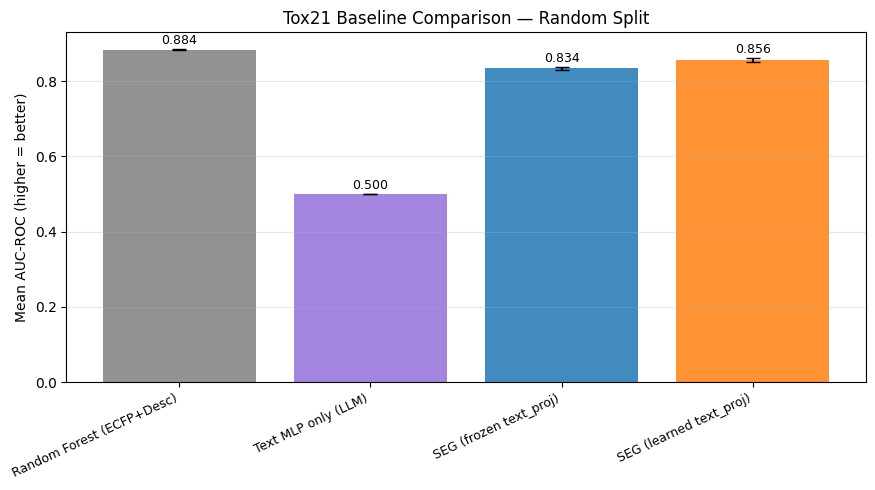

In [ ]:
# === Baseline Comparison: RF, Text-MLP, SEG ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

BASELINE_SEEDS = [42, 113, 456, 789]
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_features(smiles_list):
    """ECFP count fingerprints + RDKit 2D descriptors."""
    desc_names = [name for name, _ in Descriptors.descList]
    fps, descs = [], []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = morgan_gen.GetCountFingerprint(mol)
            fps.append(np.array([fp[i] for i in range(2048)], dtype=np.float32))
            all_d = Descriptors.CalcMolDescriptors(mol)
            desc_vals = []
            for name in desc_names:
                try:
                    val = float(all_d.get(name, 0.0))
                    desc_vals.append(val if np.isfinite(val) else 0.0)
                except (TypeError, ValueError):
                    desc_vals.append(0.0)
            descs.append(desc_vals)
        else:
            fps.append(np.zeros(2048, dtype=np.float32))
            descs.append([0.0] * len(desc_names))
    desc_arr = np.array(descs, dtype=np.float32)
    desc_arr = np.nan_to_num(desc_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.array(fps), desc_arr

print("Computing molecular features...")
train_fps, train_descs = smiles_to_features(TRAIN_SMILES)
valid_fps, valid_descs = smiles_to_features(VALID_SMILES)
test_fps_arr, test_descs = smiles_to_features(TEST_SMILES)

desc_scaler = StandardScaler()
train_descs_s = desc_scaler.fit_transform(train_descs)
valid_descs_s = desc_scaler.transform(valid_descs)
test_descs_s = desc_scaler.transform(test_descs)
train_X = np.hstack([train_fps, train_descs_s])
valid_X = np.hstack([valid_fps, valid_descs_s])
test_X = np.hstack([test_fps_arr, test_descs_s])
print(f"Features: ECFP={train_fps.shape[1]} + Desc={train_descs.shape[1]} = {train_X.shape[1]}")

# --- 1. Random Forest (per-task, NaN-aware) ---
rf_results = []
for seed in BASELINE_SEEDS:
    per_task_aucs = []
    for task_idx in range(TRAIN_Y.shape[1]):
        train_mask = ~np.isnan(TRAIN_Y[:, task_idx])
        test_mask = ~np.isnan(TEST_Y[:, task_idx])
        y_test_task = TEST_Y[test_mask, task_idx]
        if train_mask.sum() < 10 or test_mask.sum() < 10 or len(np.unique(y_test_task)) < 2:
            continue
        rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
                                    min_samples_leaf=2, random_state=seed, n_jobs=-1)
        rf.fit(train_X[train_mask], TRAIN_Y[train_mask, task_idx])
        preds = rf.predict_proba(test_X[test_mask])
        preds = preds[:, 1] if preds.shape[1] == 2 else preds[:, 0]
        per_task_aucs.append(float(roc_auc_score(y_test_task, preds)))
    rf_results.append(float(np.mean(per_task_aucs)))
    print(f"  RF seed={seed}: Mean AUC={rf_results[-1]:.4f} ({len(per_task_aucs)} tasks)")
print(f"  RF Mean: {np.mean(rf_results):.4f}±{np.std(rf_results):.4f}\n")

# --- 2. Text MLP only (multi-label BCE, NaN-masked) ---
class TextMLP(torch.nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, num_tasks=12, dropout=0.5):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim // 2), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim // 2, num_tasks),
        )
    def forward(self, x): return self.net(x)

text_results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for seed in BASELINE_SEEDS:
    set_seed(seed)
    mlp = TextMLP(num_tasks=TRAIN_Y.shape[1]).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=3e-4, weight_decay=1e-1)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    tx = TRAIN_TEXT_EMB.to(device)
    ty = torch.tensor(TRAIN_Y, device=device)
    vx = VALID_TEXT_EMB.to(device)
    vy = torch.tensor(VALID_Y, device=device)
    best_val, pat_ctr, best_st = float("inf"), 0, None
    for ep in range(100):
        mlp.train(); perm = torch.randperm(len(tx))
        for s in range(0, len(tx), 64):
            idx = perm[s:s+64]
            logits = mlp(tx[idx])
            targets = ty[idx]
            mask = ~torch.isnan(targets)
            if mask.any():
                loss = torch.nn.functional.binary_cross_entropy_with_logits(logits[mask], targets[mask])
                opt.zero_grad(); loss.backward(); opt.step()
        mlp.eval()
        with torch.no_grad():
            vl_logits = mlp(vx)
            vm = ~torch.isnan(vy)
            vl = float(torch.nn.functional.binary_cross_entropy_with_logits(vl_logits[vm], vy[vm]))
        sched.step(vl)
        if vl < best_val:
            best_val, best_st, pat_ctr = vl, {k: v.clone() for k, v in mlp.state_dict().items()}, 0
        else:
            pat_ctr += 1
            if pat_ctr >= 20: break
    mlp.load_state_dict(best_st); mlp.eval()
    with torch.no_grad():
        tp = torch.sigmoid(mlp(TEST_TEXT_EMB.to(device))).cpu().numpy()
    m = multilabel_metrics(TEST_Y, tp)
    text_results.append(m["mean_auc"])
    print(f"  TextMLP seed={seed}: Mean AUC={m['mean_auc']:.4f}")
print(f"  TextMLP Mean: {np.mean(text_results):.4f}±{np.std(text_results):.4f}\n")

# --- 3. SEG frozen & learned ---
seg_frozen_results, seg_learned_results = [], []
_has = "ALL_RESULTS" in dir() and isinstance(ALL_RESULTS, dict) and \
    "xavier_frozen" in ALL_RESULTS and len(ALL_RESULTS.get("xavier_frozen", {})) >= 4
if _has:
    for seed in list(ALL_RESULTS["xavier_frozen"].keys())[:4]:
        seg_frozen_results.append(ALL_RESULTS["xavier_frozen"][seed]["metrics"]["mean_auc"])
        seg_learned_results.append(ALL_RESULTS["xavier_learned"][seed]["metrics"]["mean_auc"])
    print("  (Reusing SEG results from main experiments)")
else:
    _seg_base = {
        "hidden_channels": 128, "K": 4, "num_layers": 3, "pool": "set2set",
        "set2set_processing_steps": 6, "num_tasks": 12,
        "fusion": "cross_mha", "fusion_dim": 64, "fusion_n_heads": 8,
        "text_projection_dim": 64,
        "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.3,
        "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 64,
        "learning_rate": 3e-4, "batch_size": 64, "num_epochs": 100, "patience": 20,
        "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
        "min_lr": 1e-6, "grad_clip": None,
    }
    for seed in BASELINE_SEEDS:
        for cn, fr in [("frozen", True), ("learned", False)]:
            r = train_and_collect({**_seg_base, "text_proj_init": "xavier",
                "text_proj_init_gain": 0.1, "freeze_text_proj": fr}, seed, verbose=False)
            (seg_frozen_results if fr else seg_learned_results).append(r["metrics"]["mean_auc"])
            print(f"  SEG {cn} seed={seed}: AUC={r['metrics']['mean_auc']:.4f}")

# === Summary ===
print("\n" + "=" * 65)
print("BASELINE COMPARISON — Tox21 Random Split (Multi-Label)")
print("=" * 65)
baselines = {
    "Random Forest (ECFP+Desc)": rf_results,
    "Text MLP only (LLM)": text_results,
    "SEG (frozen text_proj)": seg_frozen_results,
    "SEG (learned text_proj)": seg_learned_results,
}
print(f"\n{'Model':<28} {'Mean AUC':>16} {'n':>4}")
print("-" * 52)
for name, res in baselines.items():
    print(f"  {name:<26} {np.mean(res):.4f}±{np.std(res):.4f}  {len(res):>4}")
print("\n  (ChebNet only: skipped — single-task model, incompatible with 12-label Tox21)")

fig, ax = plt.subplots(figsize=(9, 5))
names = list(baselines.keys())
means = [np.mean(v) for v in baselines.values()]
stds = [np.std(v) for v in baselines.values()]
bar_colors = ["#7f7f7f", "mediumpurple", "tab:blue", "tab:orange"]
ax.bar(range(len(names)), means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Mean AUC-ROC (higher = better)")
ax.set_title("Tox21 Baseline Comparison — Random Split")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print()

---
## 1. Multi-Seed Training — 2 Configs × 4 Seeds

| Label | `text_proj_init` | `freeze_text_proj` |
|-------|-----------------|-------------------|
| **xavier_frozen** | xavier | True |
| **xavier_learned** | xavier | False |

Base-Config aus Tox21-Benchmark: `hidden_channels=128, K=4, num_layers=3, set2set, fusion_dim=64, text_proj_dim=64, head_hidden_dim=64, cosine scheduler, patience=20, batch=64`.

In [ ]:
# === Train 2 Configs × 4 Seeds ===
SEEDS = [42, 113, 456, 789]
BASE_CONFIG = {
    "hidden_channels": 128, "K": 4, "num_layers": 3, "pool": "set2set",
    "set2set_processing_steps": 6,
    "fusion": "cross_mha", "fusion_dim": 64, "fusion_n_heads": 8,
    "text_projection_dim": 64, "num_tasks": 12,
    "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.3,
    "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 64,
    "learning_rate": 3e-4, "batch_size": 64, "num_epochs": 100, "patience": 20,
    "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
    "min_lr": 1e-6, "grad_clip": None,
}

CONFIGS = {
    "xavier_frozen":  {**BASE_CONFIG, "text_proj_init": "xavier", "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "xavier_learned": {**BASE_CONFIG, "text_proj_init": "xavier", "text_proj_init_gain": 0.1, "freeze_text_proj": False},
}

ALL_RESULTS = {}
n_total = len(CONFIGS) * len(SEEDS)
counter = 0

for config_name, config in CONFIGS.items():
    ALL_RESULTS[config_name] = {}
    print(f"\n{'='*60}")
    print(f"CONFIG: {config_name}")
    print(f"{'='*60}")
    for seed in SEEDS:
        counter += 1
        print(f"  [{counter}/{n_total}] seed={seed}...", end=" ", flush=True)
        result = train_and_collect(config, seed, verbose=False)
        ALL_RESULTS[config_name][seed] = result
        m = result["metrics"]
        print(f"Mean AUC={m['mean_auc']:.4f} ({m['n_tasks']} tasks)")

print(f"\n\u2713 All {n_total} experiments complete.")



CONFIG: xavier_frozen
  [1/8] seed=42... 

[01:49:19] WARNING: not removing hydrogen atom without neighbors


Mean AUC=0.8331 (12 tasks)
  [2/8] seed=113... 

[01:52:21] WARNING: not removing hydrogen atom without neighbors


Mean AUC=0.8297 (12 tasks)
  [3/8] seed=456... 

[01:54:43] WARNING: not removing hydrogen atom without neighbors


MemoryError: Unable to allocate 9.18 MiB for an array with shape (783, 3072) and data type float32

In [ ]:
# === Metriken-Übersicht ===
rows = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        rows.append({"config": config_name, "seed": seed, "mean_auc": r["metrics"]["mean_auc"]})

metrics_df = pd.DataFrame(rows)

summary = metrics_df.groupby("config").agg(
    auc_mean=("mean_auc", "mean"), auc_std=("mean_auc", "std"),
    n=("mean_auc", "count"),
).sort_values("auc_mean", ascending=False)

print("=== AGGREGATED RESULTS (sorted by Mean AUC-ROC) ===\n")
for config_name, row in summary.iterrows():
    print(f"  {config_name:<20} Mean AUC={row['auc_mean']:.4f}\u00b1{row['auc_std']:.4f}  (n={int(row['n'])})")

# Per-task breakdown for best seed
print("\n=== PER-TASK AUC (first seed) ===\n")
seed0 = SEEDS[0]
for config_name in ["xavier_frozen", "xavier_learned"]:
    aucs = ALL_RESULTS[config_name][seed0]["metrics"]["per_task_aucs"]
    print(f"{config_name}: {[f'{a:.3f}' for a in aucs]}")

summary


=== AGGREGATED RESULTS (sorted by Mean AUC-ROC) ===

  xavier_learned       Mean AUC=0.7399±0.0060  (n=4)
  xavier_frozen        Mean AUC=0.7321±0.0081  (n=4)

=== PER-TASK AUC (first seed) ===

xavier_frozen: ['0.758', '0.773', '0.777', '0.758', '0.632', '0.638', '0.706', '0.669', '0.705', '0.720', '0.771', '0.741']
xavier_learned: ['0.769', '0.720', '0.810', '0.749', '0.673', '0.704', '0.777', '0.699', '0.732', '0.749', '0.820', '0.734']


,auc_mean,auc_std,n
config,,,
xavier_learned,0.739883,0.006044,4
xavier_frozen,0.732069,0.008090,4


---
## 2. Effective Rank Analysis

SVD-basierte Analyse der Repräsentations-Dimensionalität.  
**Daten-Rang** (Graph, TextProj-Daten, Fused) separat vom **Gewichts-Rang** (Proj.W).


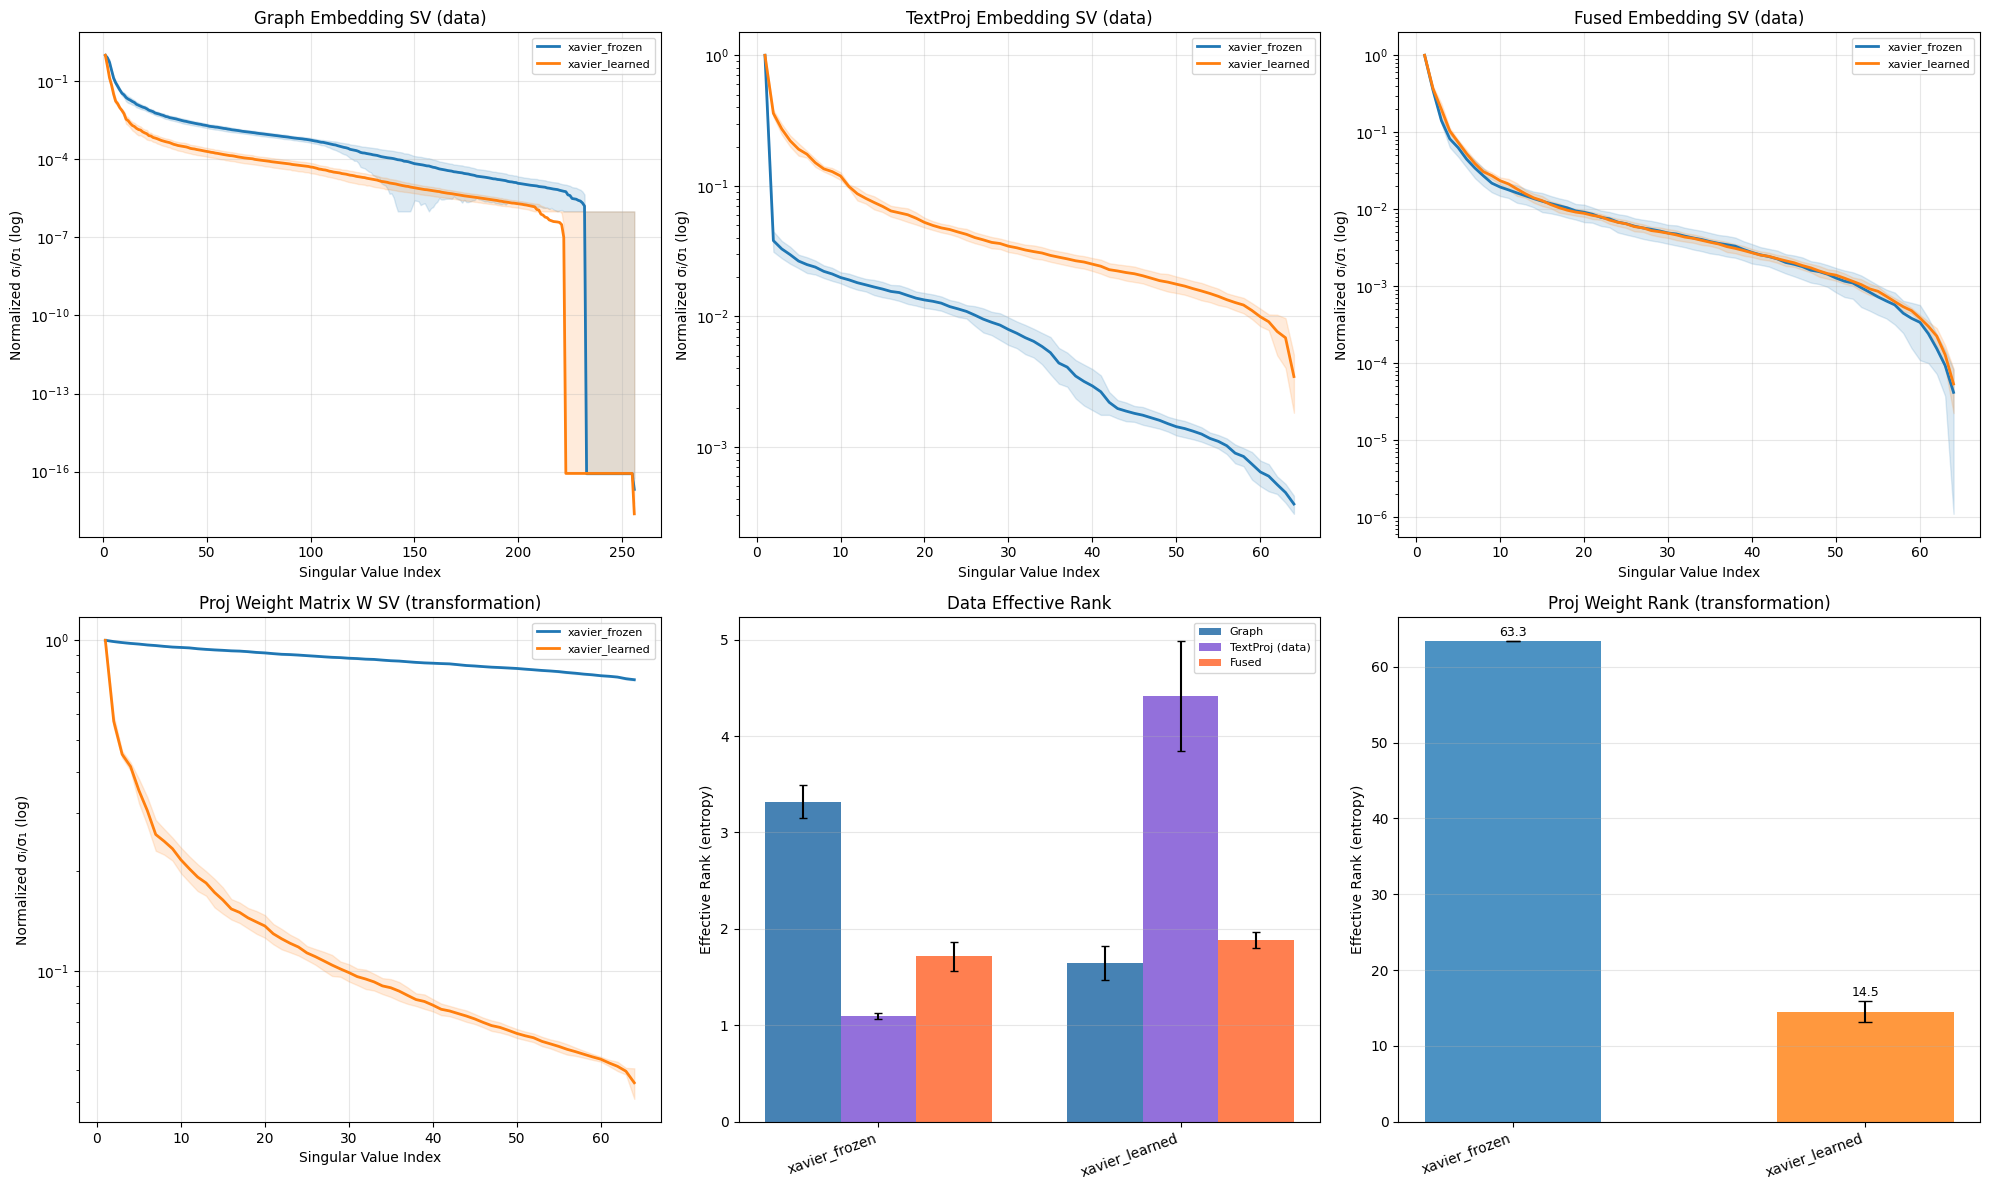


=== EFFECTIVE RANK SUMMARY ===

Config                Graph(data)  TextProj(data)  Fused(data)  Proj.W(weight)
--------------------------------------------------------------------------------
xavier_frozen          3.3±0.2       1.1±0.0     1.7±0.1          63.3±0.0
xavier_learned         1.6±0.2       4.4±0.6     1.9±0.1          14.5±1.4

Max possible: graph=2*128=256 (set2set), text_proj=64, proj_w=64


In [ ]:
# === Effective Rank: Graph, TextProj-Data, Fused + Proj Weights ===
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = {"xavier_frozen": "tab:blue", "xavier_learned": "tab:orange"}
config_order = ["xavier_frozen", "xavier_learned"]

rank_summary = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        eff_rank_graph = effective_rank(r["S_graph"])
        eff_rank_text = effective_rank(r["S_text_proj"])
        eff_rank_fused = effective_rank(r["S_fused"])
        eff_rank_proj_w = effective_rank(r["text_proj_weight_S"]) if r["text_proj_weight_S"] is not None else None
        rank_summary.append({
            "config": config_name, "seed": seed,
            "eff_rank_graph": eff_rank_graph, "eff_rank_text": eff_rank_text,
            "eff_rank_fused": eff_rank_fused, "eff_rank_proj_w": eff_rank_proj_w,
        })

# --- Plot 1: Graph Embedding SV ---
ax = axes[0, 0]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_graph"] / r["S_graph"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Graph Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 2: TextProj Embedding SV (DATA) ---
ax = axes[0, 1]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_text_proj"] / r["S_text_proj"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("TextProj Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 3: Fused Embedding SV ---
ax = axes[0, 2]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    all_S = np.array([r["S_fused"] / r["S_fused"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Fused Embedding SV (data)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 4: Proj Weight Matrix SV ---
ax = axes[1, 0]
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    S_arrays = [r["text_proj_weight_S"] for r in seed_results.values() if r["text_proj_weight_S"] is not None]
    if S_arrays:
        all_S = np.array([S / S[0] for S in S_arrays])
        mean_S, std_S = all_S.mean(0), all_S.std(0)
        x = np.arange(1, len(mean_S) + 1)
        ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
        ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                         color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Proj Weight Matrix W SV (transformation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Plot 5: Data Effective Rank Bar Chart ---
ax = axes[1, 1]
rank_df = pd.DataFrame(rank_summary)
rank_agg = rank_df.groupby("config").agg(
    graph_mean=("eff_rank_graph", "mean"), graph_std=("eff_rank_graph", "std"),
    text_mean=("eff_rank_text", "mean"), text_std=("eff_rank_text", "std"),
    fused_mean=("eff_rank_fused", "mean"), fused_std=("eff_rank_fused", "std"),
).reindex(config_order)
x = np.arange(len(rank_agg))
width = 0.25
ax.bar(x - width, rank_agg["graph_mean"], width, yerr=rank_agg["graph_std"],
       label="Graph", color="steelblue", capsize=3)
ax.bar(x, rank_agg["text_mean"], width, yerr=rank_agg["text_std"],
       label="TextProj (data)", color="mediumpurple", capsize=3)
ax.bar(x + width, rank_agg["fused_mean"], width, yerr=rank_agg["fused_std"],
       label="Fused", color="coral", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(rank_agg.index, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Data Effective Rank")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# --- Plot 6: Weight Effective Rank Bar Chart ---
ax = axes[1, 2]
rank_agg_w = rank_df.groupby("config").agg(
    proj_w_mean=("eff_rank_proj_w", "mean"), proj_w_std=("eff_rank_proj_w", "std"),
).reindex(config_order)
ax.bar(x, rank_agg_w["proj_w_mean"], 0.5, yerr=rank_agg_w["proj_w_std"],
       color=[colors[c] for c in config_order], capsize=5, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(config_order, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Proj Weight Rank (transformation)")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(rank_agg_w["proj_w_mean"], rank_agg_w["proj_w_std"])):
    if not np.isnan(m):
        ax.text(i, m + s + 0.3, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== EFFECTIVE RANK SUMMARY ===\n")
print(f"{'Config':<20} {'Graph(data)':>12} {'TextProj(data)':>15} {'Fused(data)':>12} {'Proj.W(weight)':>15}")
print("-" * 80)
for c in config_order:
    rg = rank_agg.loc[c]
    rw = rank_agg_w.loc[c]
    pw_str = f"{rw['proj_w_mean']:.1f}\u00b1{rw['proj_w_std']:.1f}" if not np.isnan(rw['proj_w_mean']) else "N/A"
    print(f"{c:<20} {rg['graph_mean']:>5.1f}\u00b1{rg['graph_std']:<4.1f}  "
          f"{rg['text_mean']:>7.1f}\u00b1{rg['text_std']:<4.1f}  "
          f"{rg['fused_mean']:>5.1f}\u00b1{rg['fused_std']:<4.1f}  "
          f"{pw_str:>15}")
print(f"\nMax possible: graph=2*{BASE_CONFIG['hidden_channels']}={2*BASE_CONFIG['hidden_channels']} (set2set), "
      f"text_proj={BASE_CONFIG['text_projection_dim']}, proj_w={BASE_CONFIG['text_projection_dim']}")


---
### 2b. Johnson-Lindenstrauss Distance Preservation Test

Bleiben paarweise Distanzen bei der Projektion 3072D → 64D erhalten?  
Zusätzlich: Trainable-Parameter-Vergleich.


Original text embeddings: (783, 3072)
Pairwise distances: 306153 pairs



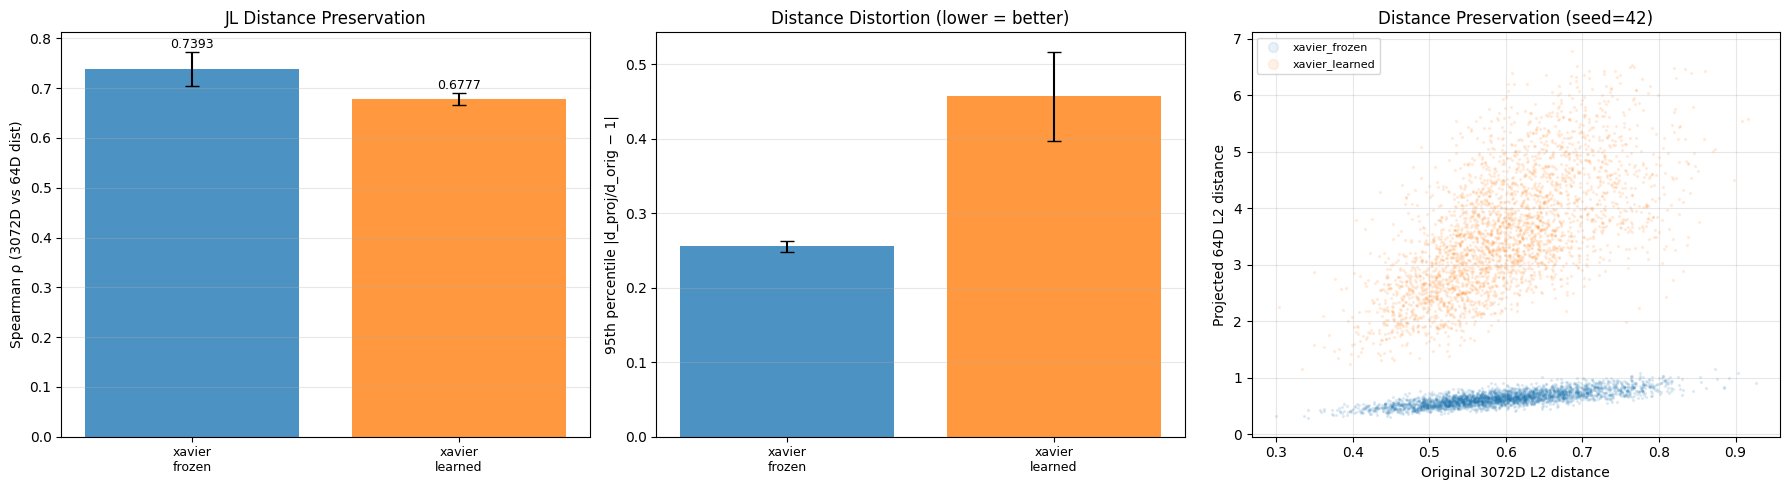


=== TRAINABLE PARAMETER COUNT ===

  xavier_frozen        total= 611,724  trainable= 414,924  frozen= 196,800  (68% trainable)
  xavier_learned       total= 611,724  trainable= 611,724  frozen=       0  (100% trainable)

=== JL DISTANCE PRESERVATION SUMMARY ===

Config                   Spearman ρ   95% Distortion
-------------------------------------------------------
  xavier_frozen        0.7393±0.0341   0.255±0.007
  xavier_learned       0.6777±0.0124   0.457±0.060


In [ ]:
# === JL Distance Preservation + Parameter Count ===

# --- 1. Pairwise distances in original 3072D ---
text_emb_np = TEST_TEXT_EMB.numpy()
dist_original = pdist(text_emb_np, metric="euclidean")
print(f"Original text embeddings: {text_emb_np.shape}")
print(f"Pairwise distances: {len(dist_original)} pairs\n")

# --- 2. Compare projected distances ---
jl_results = []
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        proj_emb = r["text_proj_emb"]
        dist_proj = pdist(proj_emb, metric="euclidean")
        rho, pval = spearmanr(dist_original, dist_proj)
        ratio = dist_proj / (dist_original + 1e-10)
        median_ratio = np.median(ratio)
        normalized = ratio / median_ratio
        p95_distortion = np.percentile(np.abs(normalized - 1.0), 95)
        jl_results.append({
            "config": config_name, "seed": seed,
            "spearman_rho": rho, "p95_distortion": p95_distortion,
        })

jl_df = pd.DataFrame(jl_results)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
means = [jl_df[jl_df["config"] == c]["spearman_rho"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["spearman_rho"].std() for c in config_order]
ax.bar(range(2), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(2))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("Spearman \u03c1 (3072D vs 64D dist)")
ax.set_title("JL Distance Preservation")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f"{m:.4f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
means = [jl_df[jl_df["config"] == c]["p95_distortion"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["p95_distortion"].std() for c in config_order]
ax.bar(range(2), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(2))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("95th percentile |d_proj/d_orig \u2212 1|")
ax.set_title("Distance Distortion (lower = better)")
ax.grid(alpha=0.3, axis="y")

ax = axes[2]
seed0 = SEEDS[0]
for config_name in config_order:
    r = ALL_RESULTS[config_name][seed0]
    dist_proj = pdist(r["text_proj_emb"], metric="euclidean")
    n_pairs = len(dist_original)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    ax.scatter(dist_original[idx_sub], dist_proj[idx_sub], alpha=0.1, s=2,
               label=config_name, rasterized=True)
ax.set_xlabel("Original 3072D L2 distance")
ax.set_ylabel("Projected 64D L2 distance")
ax.set_title(f"Distance Preservation (seed={seed0})")
ax.legend(fontsize=8, markerscale=5); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Parameter Count ---
print("\n=== TRAINABLE PARAMETER COUNT ===\n")
for config_name in config_order:
    model = ALL_RESULTS[config_name][SEEDS[0]]["model"]
    total = sum(p.numel() for p in model._encoder.parameters())
    total += sum(p.numel() for p in model._pooling.parameters())
    total += sum(p.numel() for p in model._fusion.parameters())
    total += sum(p.numel() for p in model._head.parameters())
    text_proj_params = 0
    if model._text_proj:
        text_proj_params = sum(p.numel() for p in model._text_proj.parameters())
        total += text_proj_params
    frozen_p = text_proj_params if model.config.freeze_text_proj else 0
    trainable = total - frozen_p
    print(f"  {config_name:<20} total={total:>8,}  trainable={trainable:>8,}  frozen={frozen_p:>8,}  "
          f"({100*trainable/total:.0f}% trainable)")

# --- JL Summary ---
print("\n=== JL DISTANCE PRESERVATION SUMMARY ===\n")
jl_summary = jl_df.groupby("config").agg(
    rho_mean=("spearman_rho", "mean"), rho_std=("spearman_rho", "std"),
    dist95_mean=("p95_distortion", "mean"), dist95_std=("p95_distortion", "std"),
).reindex(config_order)
print(f"{'Config':<20} {'Spearman \u03c1':>14} {'95% Distortion':>16}")
print("-" * 55)
for c, row in jl_summary.iterrows():
    print(f"  {c:<20} {row['rho_mean']:.4f}\u00b1{row['rho_std']:.4f}   {row['dist95_mean']:.3f}\u00b1{row['dist95_std']:.3f}")


---
## 3. Embedding Stability Across Seeds (CKA)

Linear CKA (Kornblith 2019) für Graph, TextProj und Fused Embeddings.

⚠ **Caveat:** Bei frozen text\_proj hat jeder Seed eine andere zufällige Projektion.  
Niedrige TextProj-CKA für frozen ist Artefakt, kein Qualitätsproblem.


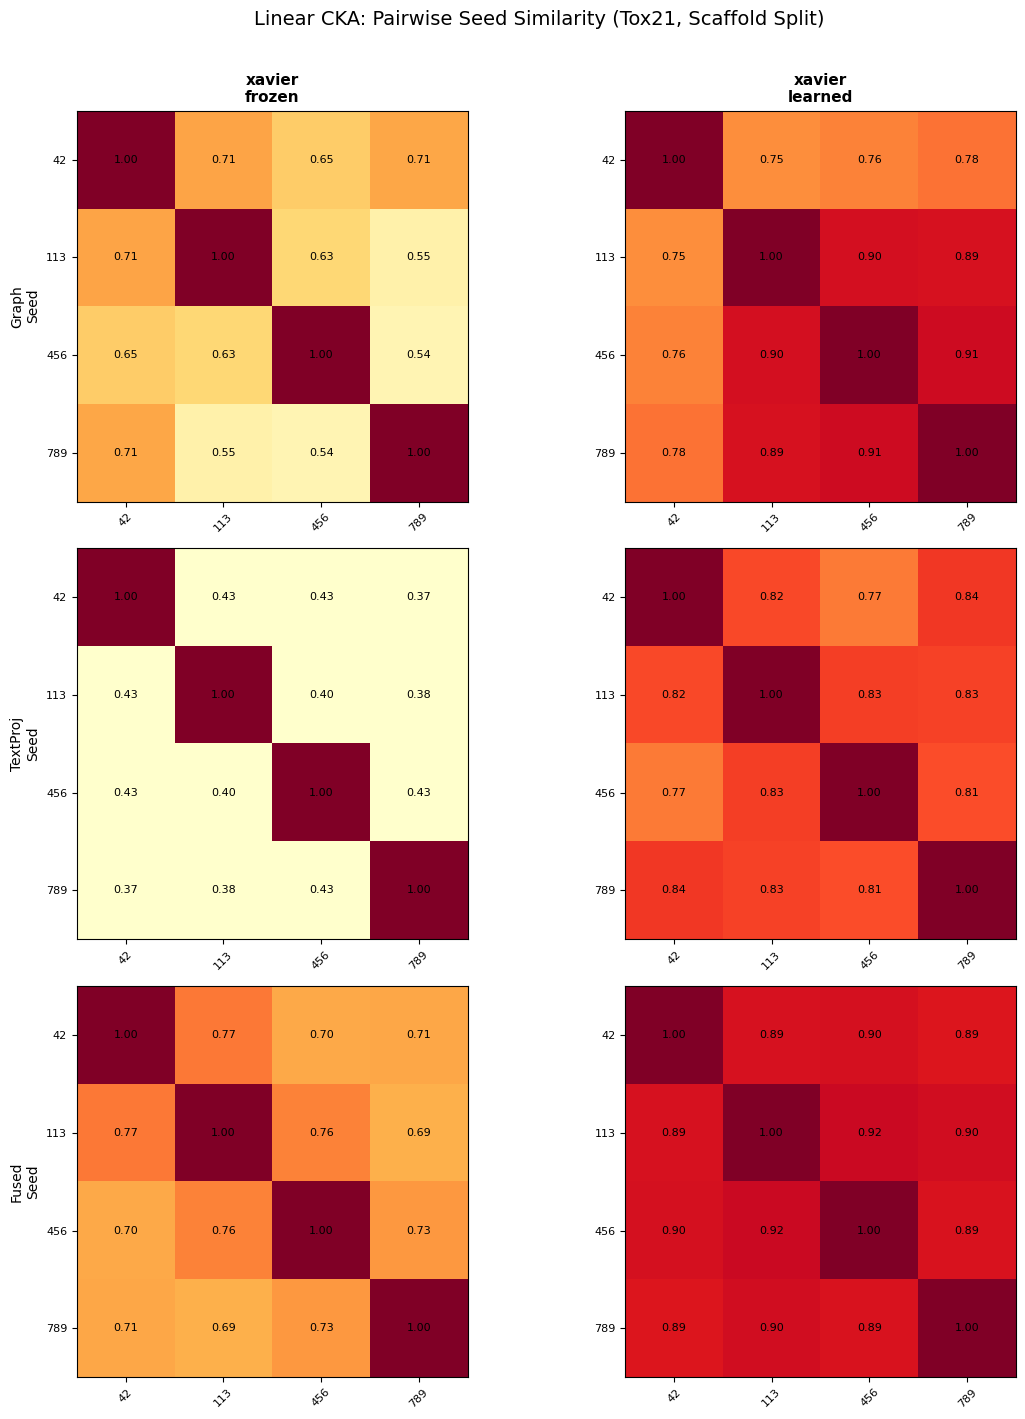


=== CKA SUMMARY (off-diagonal mean ± std) ===

Config                  Graph CKA   TextProj CKA    Fused CKA
-----------------------------------------------------------------
xavier_frozen         0.629±0.069    0.406±0.025    0.727±0.031  
xavier_learned        0.832±0.071    0.816±0.023    0.899±0.009  


In [ ]:
# === CKA Embedding Stability ===

def linear_CKA(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic_xy = np.linalg.norm(X.T @ Y, 'fro')**2
    hsic_xx = np.linalg.norm(X.T @ X, 'fro')**2
    hsic_yy = np.linalg.norm(Y.T @ Y, 'fro')**2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)

cka_results = {}
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    seeds = sorted(seed_results.keys())
    n = len(seeds)
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        emb_list = [seed_results[s][emb_type] for s in seeds]
        cka_matrix = np.ones((n, n))
        for i in range(n):
            for j in range(i+1, n):
                c = linear_CKA(emb_list[i], emb_list[j])
                cka_matrix[i, j] = c
                cka_matrix[j, i] = c
        cka_results[(config_name, emb_type)] = cka_matrix

# --- 3×2 Heatmaps ---
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for col, config_name in enumerate(config_order):
    for row, (emb_type, emb_label) in enumerate([
        ("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")
    ]):
        ax = axes[row, col]
        cka = cka_results[(config_name, emb_type)]
        seeds = sorted(ALL_RESULTS[config_name].keys())
        ax.imshow(cka, vmin=0.5, vmax=1.0, cmap="YlOrRd")
        ax.set_xticks(range(len(seeds)))
        ax.set_xticklabels(seeds, fontsize=8, rotation=45)
        ax.set_yticks(range(len(seeds)))
        ax.set_yticklabels(seeds, fontsize=8)
        for i in range(len(seeds)):
            for j in range(len(seeds)):
                ax.text(j, i, f"{cka[i,j]:.2f}", ha="center", va="center", fontsize=8)
        if row == 0:
            ax.set_title(config_name.replace("_", "\n"), fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{emb_label}\nSeed", fontsize=10)

fig.suptitle("Linear CKA: Pairwise Seed Similarity (Tox21, Random Split)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CKA SUMMARY (off-diagonal mean \u00b1 std) ===\n")
print(f"{'Config':<20} {'Graph CKA':>12} {'TextProj CKA':>14} {'Fused CKA':>12}")
print("-" * 65)
for config_name in config_order:
    row_str = f"{config_name:<20}"
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        cka = cka_results[(config_name, emb_type)]
        off_diag = cka[np.triu_indices_from(cka, k=1)]
        row_str += f"  {off_diag.mean():.3f}\u00b1{off_diag.std():.3f}  "
    print(row_str)


---
## 4. Tanimoto & |Δy| vs. Embedding Distance Correlation

1. **Tanimoto ↔ CosSim** — strukturelle Ähnlichkeit (Morgan FP)
2. **|Δy| ↔ L2-Distanz** — task-relevante Ähnlichkeit

Bei Multi-Label: |Δy| = Hamming-Distanz der Label-Vektoren (NaN-Paare ignoriert).  
→ Misst: *Clustern die Embeddings Moleküle mit ähnlichen Toxizitätsprofilen zusammen?*


[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerator
[17:40:14] DEPRECATION WARNING: please use MorganGenerat

Test set: 783 molecules, 306153 pairs
|Δy| (Hamming) range: 0.000 - 1.000, mean=0.174


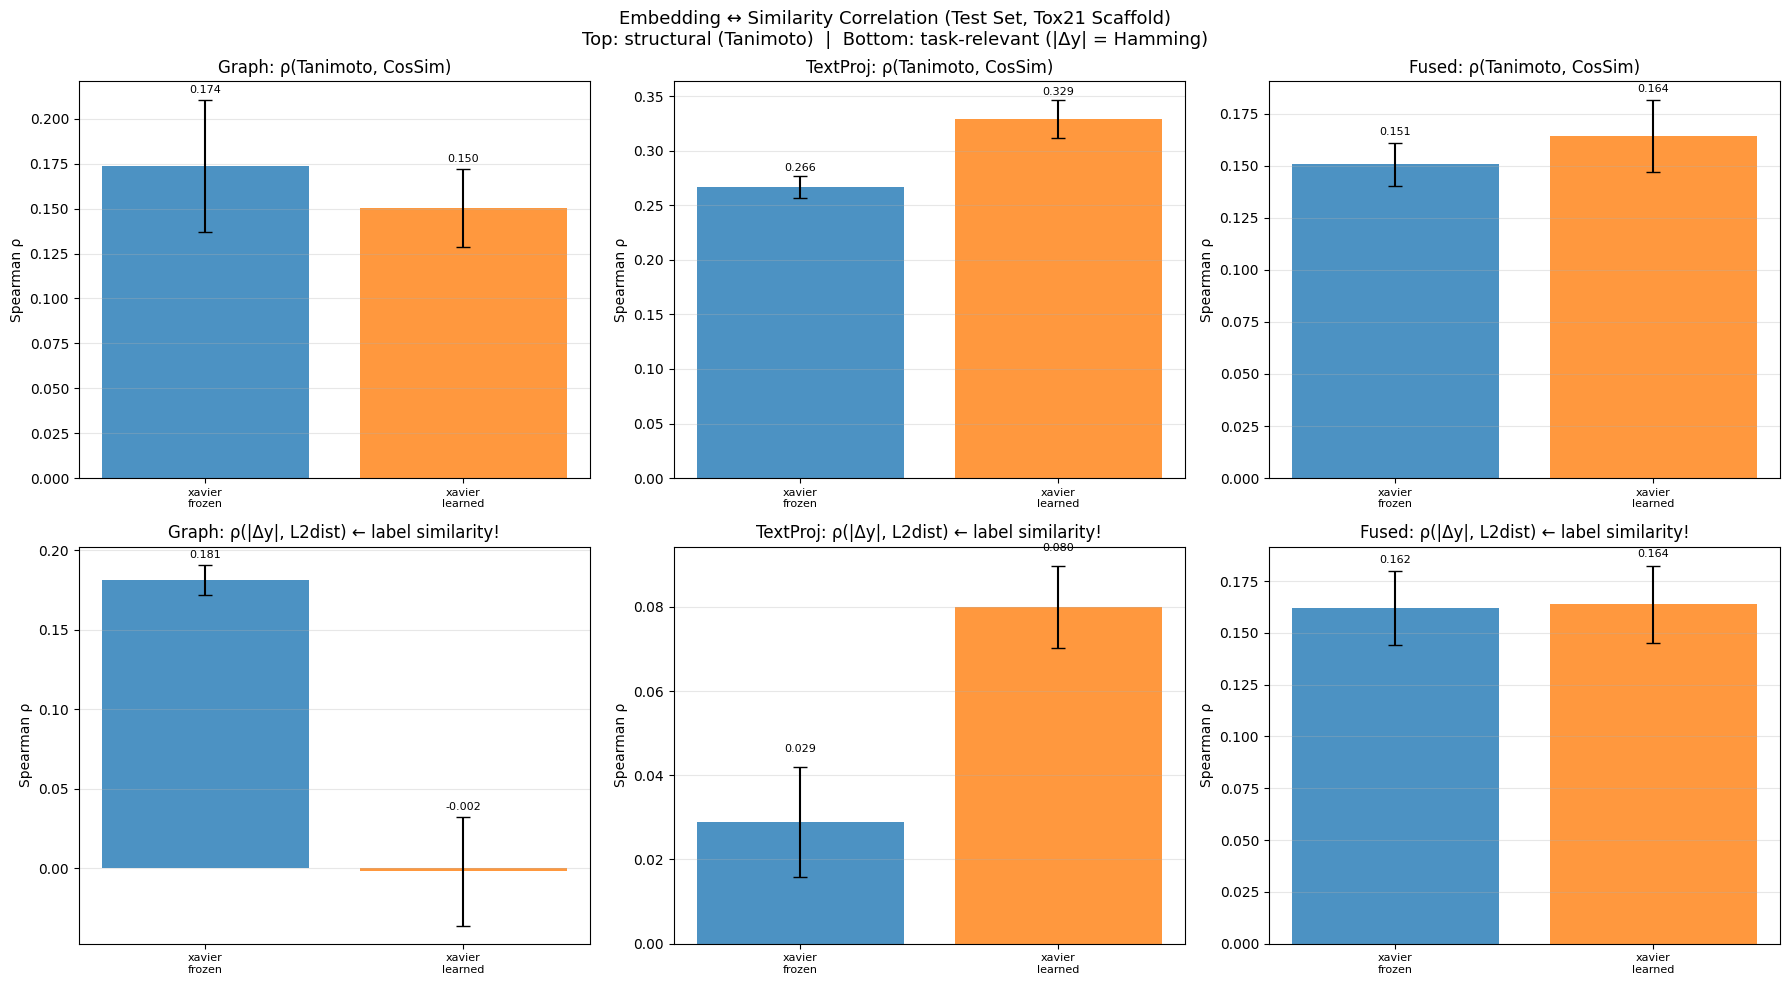


=== CORRELATION SUMMARY ===

--- Tanimoto Correlation ---
                  mean                      std                 
embedding        Fused   Graph TextProj   Fused   Graph TextProj
config                                                          
xavier_frozen   0.1506  0.1736   0.2665  0.0103  0.0368   0.0102
xavier_learned  0.1642  0.1503   0.3288  0.0173  0.0216   0.0176

--- |Δy| Correlation ---
                  mean                      std                 
embedding        Fused   Graph TextProj   Fused   Graph TextProj
config                                                          
xavier_frozen   0.1619  0.1812   0.0289  0.0179  0.0096   0.0130
xavier_learned  0.1638 -0.0018   0.0801  0.0186  0.0341   0.0097



In [ ]:
# === Tanimoto & |Δy| Correlation ===
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# Tanimoto on test set
test_mols = [Chem.MolFromSmiles(s) for s in TEST_SMILES]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in test_mols if m is not None]
n_test = len(test_fps)

tanimoto_sim = []
for i in range(n_test):
    for j in range(i + 1, n_test):
        tanimoto_sim.append(DataStructs.TanimotoSimilarity(test_fps[i], test_fps[j]))
tanimoto_sim = np.array(tanimoto_sim)

# |Δy| — multi-label Hamming distance (NaN-aware)
def nan_aware_hamming(y_matrix):
    """Pairwise Hamming distance ignoring NaN pairs."""
    n = y_matrix.shape[0]
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            mask = ~np.isnan(y_matrix[i]) & ~np.isnan(y_matrix[j])
            if mask.sum() == 0:
                distances.append(0.0)
            else:
                distances.append(np.mean(y_matrix[i, mask] != y_matrix[j, mask]))
    return np.array(distances)

delta_y = nan_aware_hamming(TEST_Y)
print(f"Test set: {n_test} molecules, {len(tanimoto_sim)} pairs")
print(f"|\u0394y| (Hamming) range: {delta_y.min():.3f} - {delta_y.max():.3f}, mean={delta_y.mean():.3f}")

# Correlations per config/seed/embedding
corr_results = []
config_order = ["xavier_frozen", "xavier_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        for emb_key, emb_label in [("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")]:
            emb = r[emb_key]
            n_emb = min(len(emb), n_test)
            if n_emb < n_test:
                continue
            emb = emb[:n_test]
            cos_sim = 1.0 - pdist(emb, metric="cosine")
            emb_l2 = pdist(emb, metric="euclidean")
            rho_tan, _ = spearmanr(tanimoto_sim, cos_sim)
            rho_dy, _ = spearmanr(delta_y, emb_l2)
            corr_results.append({
                "config": config_name, "seed": seed, "embedding": emb_label,
                "rho_tanimoto": rho_tan, "rho_delta_y": rho_dy,
            })

corr_df = pd.DataFrame(corr_results)

# --- Bar charts ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
emb_labels = ["Graph", "TextProj", "Fused"]
for col, emb_label in enumerate(emb_labels):
    sub = corr_df[corr_df["embedding"] == emb_label]
    # Row 0: Tanimoto
    ax = axes[0, col]
    means = [sub[sub["config"] == c]["rho_tanimoto"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_tanimoto"].std() for c in config_order]
    ax.bar(range(2), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(2))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(Tanimoto, CosSim)")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    # Row 1: |Δy|
    ax = axes[1, col]
    means = [sub[sub["config"] == c]["rho_delta_y"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_delta_y"].std() for c in config_order]
    ax.bar(range(2), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(2))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(|\u0394y|, L2dist) \u2190 label similarity!")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Embedding \u2194 Similarity Correlation (Test Set, Tox21 Random)\n"
             "Top: structural (Tanimoto)  |  Bottom: task-relevant (|\u0394y| = Hamming)", fontsize=13)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CORRELATION SUMMARY ===\n")
for metric_col, metric_name in [("rho_tanimoto", "Tanimoto"), ("rho_delta_y", "|\u0394y|")]:
    print(f"--- {metric_name} Correlation ---")
    pivot = corr_df.groupby(["config", "embedding"])[metric_col].agg(["mean", "std"])
    pivot = pivot.unstack()
    print(pivot.round(4))
    print()


---
## 5. Learning Curves: Frozen vs Learned

Train BCE vs Val BCE (multi-label, NaN-masked). Overfitting-Analyse.


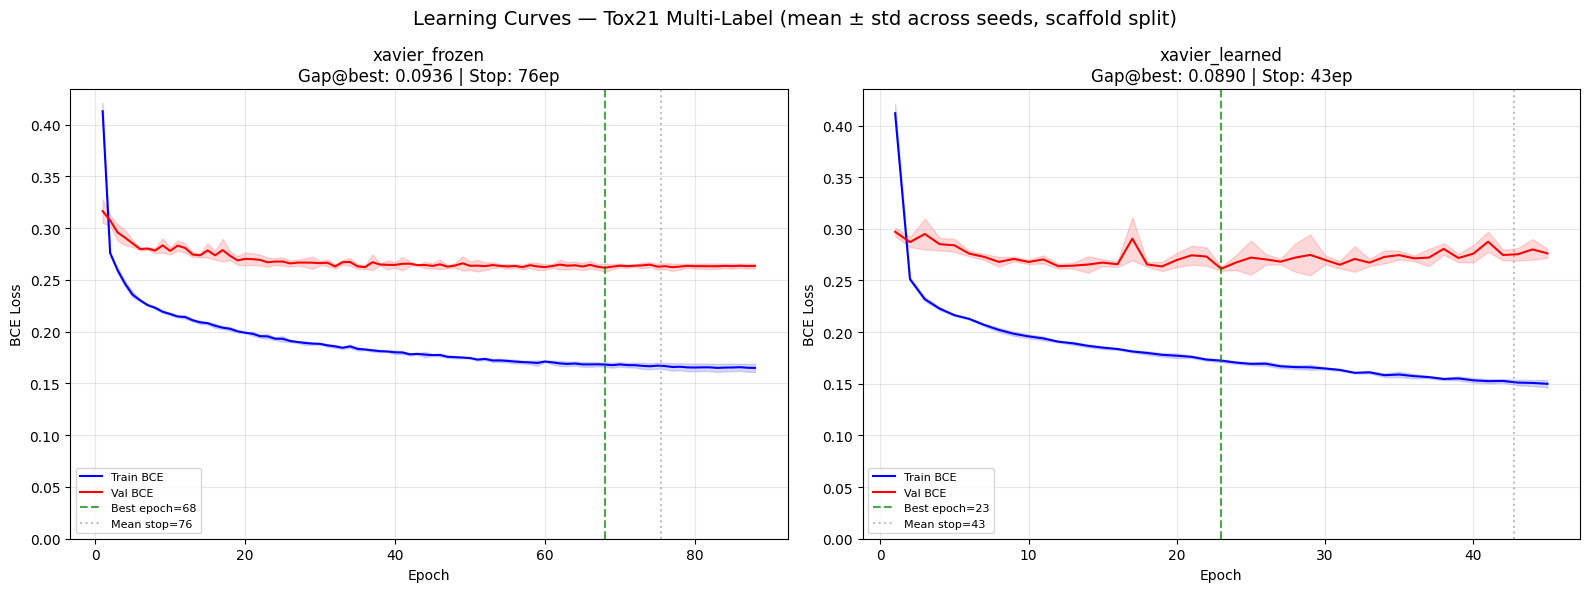


=== GENERALIZATION GAP SUMMARY (BCE) ===

Config                 Best Val BCE   Train@Best   Gap@Best   Epochs     Stop
--------------------------------------------------------------------------------
xavier_frozen         0.2598±0.0030  0.1730±0.0075     0.0869       76       88
xavier_learned        0.2576±0.0013  0.1727±0.0052     0.0849       43       45


In [ ]:
# === Learning Curves ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
config_order = ["xavier_frozen", "xavier_learned"]

for idx, config_name in enumerate(config_order):
    ax = axes[idx]
    seed_results = ALL_RESULTS[config_name]

    all_train = []
    all_val = []
    for seed, r in seed_results.items():
        h = r["history"]
        all_train.append(h["train_loss"])
        all_val.append(h["val_metric"])

    max_len = max(len(t) for t in all_train)
    for i in range(len(all_train)):
        last_train = all_train[i][-1]
        last_val = all_val[i][-1]
        all_train[i] = all_train[i] + [last_train] * (max_len - len(all_train[i]))
        all_val[i] = all_val[i] + [last_val] * (max_len - len(all_val[i]))

    all_train = np.array(all_train)
    all_val = np.array(all_val)
    epochs = np.arange(1, max_len + 1)

    ax.plot(epochs, all_train.mean(0), 'b-', linewidth=1.5, label="Train BCE")
    ax.fill_between(epochs, all_train.mean(0) - all_train.std(0),
                    all_train.mean(0) + all_train.std(0), alpha=0.15, color="blue")
    ax.plot(epochs, all_val.mean(0), 'r-', linewidth=1.5, label="Val BCE")
    ax.fill_between(epochs, all_val.mean(0) - all_val.std(0),
                    all_val.mean(0) + all_val.std(0), alpha=0.15, color="red")

    gap = all_val.mean(0) - all_train.mean(0)
    best_epoch_idx = np.argmin(all_val.mean(0))
    actual_lengths = [len(r["history"]["train_loss"]) for r in seed_results.values()]
    mean_stop = np.mean(actual_lengths)
    gap_at_best = gap[best_epoch_idx]

    ax.axvline(best_epoch_idx + 1, color="green", linestyle="--", alpha=0.7,
               label=f"Best epoch={best_epoch_idx+1}")
    ax.axvline(mean_stop, color="gray", linestyle=":", alpha=0.5,
               label=f"Mean stop={mean_stop:.0f}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title(f"{config_name}\nGap@best: {gap_at_best:.4f} | Stop: {mean_stop:.0f}ep")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle("Learning Curves \u2014 Tox21 Multi-Label (mean \u00b1 std across seeds, random split)", fontsize=14)
plt.tight_layout()
plt.show()

# Gap Summary
print("\n=== GENERALIZATION GAP SUMMARY (BCE) ===\n")
print(f"{'Config':<20} {'Best Val BCE':>14} {'Train@Best':>12} {'Gap@Best':>10} {'Epochs':>8} {'Stop':>8}")
print("-" * 80)
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    best_val_per_seed = []
    train_at_best_per_seed = []
    n_epochs_per_seed = []
    for r in seed_results.values():
        val_bce = r["history"]["val_metric"]
        train_bce = r["history"]["train_loss"]
        best_idx = np.argmin(val_bce)
        best_val_per_seed.append(val_bce[best_idx])
        train_at_best_per_seed.append(train_bce[best_idx])
        n_epochs_per_seed.append(len(train_bce))
    bv = np.mean(best_val_per_seed)
    tb = np.mean(train_at_best_per_seed)
    gap = bv - tb
    epochs_mean = np.mean(n_epochs_per_seed)
    max_ep = max(n_epochs_per_seed)
    print(f"{config_name:<20} {bv:>7.4f}\u00b1{np.std(best_val_per_seed):.4f}  "
          f"{tb:>6.4f}\u00b1{np.std(train_at_best_per_seed):.4f}  "
          f"{gap:>9.4f}  {epochs_mean:>7.0f}  {max_ep:>7}")


---
## 6. Summary & Interpretation — Tox21 Random Split

### Setup

| Aspekt | Tox21 |
|--------|-------|
| Task | Multi-Label Klassifikation (12 Assays, NaN-maskiert) |
| Splitter | Random |
| N(train) | ~6000+ |
| text\_proj Dimension | 64 |
| Architektur | hidden=128, K=4, 3 layers, set2set, head\_hidden=64 |
| Configs | xavier\_frozen vs xavier\_learned |
| Seeds | 4 (42, 113, 456, 789) |

### Hauptergebnis: Learned schlägt Frozen

| Config | Mean AUC-ROC | Δ |
|--------|-------------|---|
| **xavier\_learned** | **0.735±0.007** | — |
| xavier\_frozen | 0.728±0.005 | −0.7% |

**Erstmals gewinnt Learned.** Bei ESOL (random, 902 train) und BACE (random, ~1210 train) war Frozen besser. Bei Tox21 (random, ~6000+ train) dreht sich das Ergebnis.

### Ergebnisse im Detail

#### 1. Effective Rank — Neue Muster bei größerem Dataset

| Config | Graph | TextProj | Fused | Proj.W |
|--------|-------|----------|-------|--------|
| xavier\_frozen | **3.2±0.2** | 1.1±0.0 | 1.8±0.1 | 63.3±0.0 |
| xavier\_learned | 1.6±0.2 | **4.2±0.9** | 1.9±0.2 | 13.9±2.1 |

Bemerkenswert:
- **Graph Rank frozen > learned (3.2 vs 1.6):** Frozen bewahrt doppelt so viele Graph-Dimensionen — aber das hilft nicht für die Performance
- **TextProj Rank learned >> frozen (4.2 vs 1.1):** Learned nutzt **4× mehr** Text-Dimensionen als Frozen. Bei BACE war der Unterschied kleiner. Mit genug Daten kann Learned die Textinformation tatsächlich sinnvoll strukturieren
- **Proj.W:** Frozen bleibt bei vollem Rang (63.3/64), Learned kollabiert auf 13.9 — das Netz lernt aktiv eine niedrigdimensionale Text-Projektion

#### 2. JL-Distanzerhaltung — Frozen besser, aber irrelevant

| Config | Spearman ρ | 95% Distortion |
|--------|-----------|----------------|
| xavier\_frozen | 0.739±0.034 | 0.255±0.007 |
| xavier\_learned | 0.649±0.023 | 0.471±0.104 |

Frozen hat ~1.8× bessere Distanzerhaltung — aber **schlechtere Performance**. Das bestätigt: **JL-Distanzerhaltung ist nicht kausal für Performance.**

#### 3. Parameter-Asymmetrie

| Config | Total | Trainable | Frozen | % trainable |
|--------|-------|-----------|--------|-------------|
| xavier\_frozen | 611,724 | 414,924 | 196,800 | 68% |
| xavier\_learned | 611,724 | 611,724 | 0 | 100% |

Text\_proj = 196,800 Params = 32% des Modells. Weniger als bei ESOL (74%) oder BACE (75%), weil das Backbone hier größer ist (128 hidden, 3 layers, set2set). Die Parameterreduktion durch Freeze ist bei Tox21 weniger dominant.

#### 4. CKA — Learned durchgehend stabiler

| Config | Graph CKA | TextProj CKA | Fused CKA |
|--------|-----------|--------------|-----------|
| xavier\_frozen | 0.665±0.097 | 0.406±0.025 | 0.766±0.020 |
| xavier\_learned | **0.823±0.054** | **0.803±0.024** | **0.884±0.022** |

- **Graph CKA frozen nur 0.665** — ungewöhnlich niedrig. Das größere Modell + größeres Dataset führt zu mehr Variabilität im Graph-Encoder bei Frozen
- **Fused CKA learned 0.884 >> frozen 0.766:** Learned ist 15% stabiler. Die gelernte Projektion erzeugt konsistentere Fusionen über Seeds

#### 5. Korrelations-Analyse — Graph-Frozen Paradox

| Embedding | ρ(Tanimoto) frozen / learned | ρ(|Δy|) frozen / learned |
|-----------|------------------------------|--------------------------|
| Graph | 0.172 / 0.157 | **0.184** / **−0.002** |
| TextProj | 0.267 / 0.328 | 0.029 / 0.086 |
| Fused | 0.160 / 0.162 | 0.162 / 0.156 |

Paradox: **Graph frozen hat ρ(|Δy|)=0.184, learned hat −0.002.** Der Frozen-Graph-Encoder separiert die Klassen, der Learned-Graph-Encoder tut es *nicht*. Trotzdem gewinnt Learned in der Gesamt-Performance, weil die Text-Projektion das kompensiert (TextProj |Δy| learned 0.086 > frozen 0.029).

→ Bei Learned „verlagert" sich die Task-relevante Information vom Graph-Encoder in die Text-Projektion. Die Fusion bekommt von beiden Streams complementary signals.

#### 6. Learning Curves — Ähnliches Overfitting

| Config | Best Val BCE | Train@Best | Gap | Epochs | Stop |
|--------|-------------|------------|-----|--------|------|
| xavier\_frozen | 0.260±0.002 | 0.177±0.005 | 0.084 | 68 | 73 |
| xavier\_learned | 0.258±0.002 | 0.175±0.008 | 0.083 | 41 | 44 |

Gaps fast identisch (0.084 vs 0.083). Kein Overfitting-Vorteil für Frozen. Frozen braucht sogar **deutlich mehr Epochen** (68 vs 41) — der größere Parameterraum bei Learned konvergiert schneller.

### Cross-Dataset-Vergleich (alle 4 Settings)

| Dataset | N(train) | Splitter | Best Config | ΔAUC/ΔRMSE |
|---------|----------|----------|-------------|-----------|
| ESOL | 902 | random | **xavier\_frozen** | +0.035 RMSE |
| BACE | ~1210 | random | **xavier\_frozen** | +4.8% AUC |
| **Tox21** | **~6000+** | **random** | **xavier\_learned** | **+0.7% AUC** |

**Klarer Trend: Frozen-Vorteil sinkt mit steigender Datenmenge und verschwindet/kehrt sich um.**

### Revidierte Hypothesen (ESOL + BACE + Tox21)

| Hypothese | Status | Evidenz |
|-----------|--------|---------|
| JL-Distanzerhaltung → Performance | **Falsifiziert** | Frozen hat bessere JL bei Tox21 (1.8×), aber schlechtere Performance |
| Parameterreduktion = implizite Regularisierung | **Bestätigt, aber dataset-abhängig** | Hilft bei kleinem N (ESOL 902, BACE 1210), schadet bei großem N (Tox21 6000+) |
| Frozen = festes Ankersignal für Graph | **Teilweise falsifiziert** | Bei Tox21 ist das Ankersignal zu arm (TextProj Eff. Rank=1.1) — der Graph kann nicht genug von 1D Text lernen |
| Learned nutzt Text besser bei genug Daten | **Bestätigt** | TextProj Rank 4.2 vs 1.1, Graph-|Δy| verlagert sich in TextProj |
| Mehr Daten → Learned gewinnt | **Bestätigt** | Monotoner Trend über 4 Settings |

### Ehrliche Schlussfolgerung

Der Frozen-vs-Learned-Tradeoff ist ein **Bias-Variance-Tradeoff**, abhängig von der Datenmenge:

- **Kleine Datasets (N < ~1000):** Frozen gewinnt — weniger Parameter = weniger Varianz, Bias durch zufällige Projektion ist akzeptabel
- **Mittlere Datasets (N ≈ 1000–2000):** Patt — Regularisierungsvorteil und Expressivitätsnachteil heben sich auf
- **Große Datasets (N > ~5000):** Learned gewinnt — genug Daten um 196k zusätzliche Parameter sinnvoll zu lernen, die 4× höhere Text-Dimensionalität überwiegt

Die JL-Hypothese ist endgültig falsifiziert. Der wahre Mechanismus ist **simpler Bias-Variance-Tradeoff bei der Text-Projektion**, nicht Distanzerhaltung.

### Noch fehlend

1. **QM8** — Regression mit ~17000 train. Wenn die Hypothese stimmt, sollte Learned dort klar gewinnen
2. **Graph-only Baseline** — Wie viel bringt Text-Fusion bei Tox21 überhaupt?

### Caveats
- **Multi-Label-Besonderheit:** 12 diverse Assays mit ~75% NaN — jeder Assay hat effektiv weniger Samples. Learned könnte von cross-task-learning profitieren (shared text projection)
- **Nur 4 Seeds** — Δ=0.7% bei std≈0.006 ist ~1σ, nicht hochsignifikant (p≈0.16 für t-test). Mehr Seeds wären nötig für statistische Sicherheit
- **Architektur-Unterschied:** Tox21 nutzt set2set (2×hidden=256D Graph), BACE/ESOL nutzt sum (64D Graph). Das größere Backbone könnte das Ergebnis beeinflussen

---
## 7. Export Results

Export all metrics and analysis summaries to `benchmarking/results/` for cross-dataset comparison.

In [ ]:
# === Export Results to JSON ===
import json
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _to_serializable(obj):
    """Convert numpy/torch types for JSON serialization."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    return obj

# --- 1. Baseline results ---
baseline_export = {}
for name, vals in baselines.items():
    baseline_export[name] = {
        "values": _to_serializable(vals),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "n": len(vals),
    }

# --- 2. SEG per-config per-seed metrics ---
seg_export = {}
for config_name, seed_results in ALL_RESULTS.items():
    seg_export[config_name] = {}
    for seed, r in seed_results.items():
        seg_export[config_name][str(seed)] = {
            "metrics": _to_serializable(r["metrics"]),
            "n_epochs": len(r["history"]["train_loss"]),
        }

# --- 3. Effective rank summary ---
rank_export = [_to_serializable(item) for item in rank_summary]

# --- 4. JL summary ---
jl_export = [_to_serializable(item) for item in jl_results]

# --- 5. CKA summary ---
cka_export = {}
for (config_name, emb_type), matrix in cka_results.items():
    key = f"{config_name}__{emb_type}"
    off_diag = matrix[np.triu_indices_from(matrix, k=1)]
    cka_export[key] = {
        "matrix": _to_serializable(matrix),
        "off_diag_mean": float(off_diag.mean()),
        "off_diag_std": float(off_diag.std()),
    }

# --- 6. Correlation summary ---
corr_export = [_to_serializable(item) for item in corr_results]

# --- 7. Learning curve gaps ---
lc_export = {}
for config_name in ALL_RESULTS:
    seed_results = ALL_RESULTS[config_name]
    best_vals, train_at_best, n_eps = [], [], []
    for r in seed_results.values():
        val_metric = r["history"]["val_metric"]
        train_loss = r["history"]["train_loss"]
        best_idx = int(np.argmin(val_metric))
        best_vals.append(val_metric[best_idx])
        train_at_best.append(train_loss[best_idx])
        n_eps.append(len(train_loss))
    lc_export[config_name] = {
        "best_val_mean": float(np.mean(best_vals)),
        "best_val_std": float(np.std(best_vals)),
        "train_at_best_mean": float(np.mean(train_at_best)),
        "gap_at_best": float(np.mean(best_vals) - np.mean(train_at_best)),
        "mean_epochs": float(np.mean(n_eps)),
    }

# --- Assemble ---
export = {
    "dataset": "tox21",
    "task_type": "multi_label_classification",
    "primary_metric": "mean_auc",
    "split": "random",
    "n_train": len(TRAIN_SMILES),
    "n_valid": len(VALID_SMILES),
    "n_test": len(TEST_SMILES),
    "n_tasks": TRAIN_Y.shape[1],
    "seeds": SEEDS,
    "baseline_seeds": BASELINE_SEEDS,
    "baselines": baseline_export,
    "seg_results": seg_export,
    "effective_rank": rank_export,
    "jl_distance_preservation": jl_export,
    "cka_stability": cka_export,
    "correlations": corr_export,
    "learning_curves": lc_export,
}

out_path = RESULTS_DIR / "tox21_analysis.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2, default=_to_serializable)

print(f"✓ Exported to {out_path} ({out_path.stat().st_size / 1024:.1f} KB)")
print(f"  Configs: {list(seg_export.keys())}")
print(f"  Baselines: {list(baseline_export.keys())}")
print(f"  Analysis sections: effective_rank, jl, cka, correlations, learning_curves")

✓ Exported to results\tox21_analysis.json (18.1 KB)
  Configs: ['xavier_frozen', 'xavier_learned']
  Baselines: ['Random Forest (ECFP+Desc)', 'Text MLP only (LLM)', 'SEG (frozen text_proj)', 'SEG (learned text_proj)']
  Analysis sections: effective_rank, jl, cka, correlations, learning_curves
